
# UrbanCart, Milestone 1: Predicting Next Month's Customer Spend

Here is the story so far.

UrbanCart is a mid-size online retailer that sells home goods and electronics. They have been in business long enough to build up a solid customer database, but they have always made decisions on gut feeling. Lately, that has started to hurt them. Some of their best customers quietly stop spending as much, and by the time finance notices, the damage to cash flow and inventory planning is already done.

"We keep getting blindsided by how much customers spend month to month. Some of our best customers go quiet for no obvious reason, and we cannot plan inventory or cash flow on guesswork anymore. Can you help us see this coming?"
That is why UrbanCart brought in a freelance machine learning engineer. That is the role this notebook plays.

The finance team handed over a spreadsheet of about 20,000 past customers. For each one, we know how long they have been active, what their average order looks like, how many orders they placed last quarter, and which region they are in. We also know what they actually went on to spend the following month, because this is historical data. That last piece, `NextMonthSpend`, is the number we are trying to predict for future customers, where we will not have the luxury of already knowing the answer.
This notebook tells the whole story in order. We look at the data honestly first. We build a couple of new, smarter features and prove they are worth keeping instead of just assuming it. We decide, in advance, how we will judge success, so we are not tempted to pick whatever metric flatters our favorite model later. We split the data into three parts, not two, so we have a safe place to make decisions and a completely untouched set for the final verdict. Then we solve the problem twice, fully and independently, with Linear Regression and then Random Forest, before ever placing them side by side and picking a winner.

### Roadmap for this notebook

| # | Section | What we're doing |
|---|---------|-------------------|
| 1 | Setup | Import the libraries we need |
| 2 | Load and inspect | First look at the data |
| 3 | Data quality checks | Missing values, duplicates, impossible values |
| 4 | Outlier check | Look, understand, and keep them |
| 5 | Exploratory analysis | Charts to understand relationships |
| 6 | Feature engineering | Build new features from what we know about the business |
| 7 | Choosing our evaluation metrics | Decide how we will judge success, before we see any results |
| 8 | Feature and target split | Baseline features versus engineered features |
| 9 | Encoding categorical columns | Turn text into numbers, safely |
| 10 | Three way split | Train, validation, and test, done before any fitting |
| 11 | Model 1, Linear Regression | Choose the best setup on validation data, then check it once on the test set |
| 12 | Model 2, Random Forest | Same process, tuned and checked independently |
| 13 | Head to head comparison | Both models' test set results, side by side |
| 14 | Recommendation | The final call, backed by evidence, with an honest tradeoff

## 1. Setup

We start by loading the tools we'll need for the whole notebook: `pandas` and `numpy` for handling data, `matplotlib` and `seaborn` for charts, and `scikit-learn` for the modeling and scoring.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42  # a fixed seed so every split and every model gives the same result each time we run this


## 2. Load and Inspect the Data

The finance team gave us a spreadsheet of about 20,000 past customers. For each one we know `MonthsActive`, `AvgOrderValue`, `NumOrdersLastQuarter`, and `Region`, and we also know what they actually went on to spend the following month, `NextMonthSpend`. That last column is our target. It is the answer we already know for the past, and the thing we want to predict for the future.


In [2]:
df = pd.read_csv("milestone-1-customer-spend.csv")
print(f"Shape: {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head()


Shape: 20,000 rows and 5 columns


,MonthsActive,AvgOrderValue,NumOrdersLastQuarter,Region,NextMonthSpend
0,6,25.70,7,South,88.51
1,47,85.81,5,East,137.62
2,40,87.63,7,East,148.99
3,27,45.16,4,East,101.25
4,26,67.26,7,East,136.76


## 3. Data Quality Checks

Before we build anything, we check that the data is actually trustworthy. Three simple questions: is anything missing, is anything repeated, and does anything look impossible, like a negative number of orders or negative spend. If we find problems here, we fix them now, before splitting the data, so we don't bake errors into every later step.


In [3]:
print("Missing values per column:")
print(df.isna().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

checks = {
    "MonthsActive < 0":         (df["MonthsActive"] < 0).sum(),
    "AvgOrderValue <= 0":       (df["AvgOrderValue"] <= 0).sum(),
    "NumOrdersLastQuarter < 0": (df["NumOrdersLastQuarter"] < 0).sum(),
    "NextMonthSpend < 0":       (df["NextMonthSpend"] < 0).sum(),
}
for check, count in checks.items():
    print(f"{check:30s} -> {'looks fine' if count == 0 else f'{count} rows to check!'}")

print("\nRegions found:", df["Region"].unique().tolist())


Missing values per column:
MonthsActive            0
AvgOrderValue           0
NumOrdersLastQuarter    0
Region                  0
NextMonthSpend          0
dtype: int64

Duplicate rows: 0
MonthsActive < 0               -> looks fine
AvgOrderValue <= 0             -> looks fine
NumOrdersLastQuarter < 0       -> looks fine
NextMonthSpend < 0             -> looks fine

Regions found: ['South', 'East', 'West', 'North']


Good news. There are no missing values, no duplicate rows, and no impossible numbers anywhere. `Region` only contains four expected categories. This is a clean dataset, so we can move straight on without any repairs.


## 4. Outlier Check: Look, Understand, and Keep

Some customers spend far more than average, and some spend far less. These are not mistakes. They are probably real people, and they may well be exactly the high value or low value customers the finance team is worried about. If we deleted them, we would be teaching the model to ignore the customers who matter most. So in this section we look closely at these unusual rows, understand where they sit, and then leave every single one in the dataset.

We use a simple rule called the IQR rule just to count how many rows sit far from the middle of the pack. We are only counting them here, never removing them.


In [4]:
numeric_cols = ["MonthsActive", "AvgOrderValue", "NumOrdersLastQuarter", "NextMonthSpend"]

for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:24s} -> {n_outliers:4d} rows ({n_outliers/len(df)*100:4.1f}%) sit outside [{lower:,.1f}, {upper:,.1f}]")


MonthsActive             ->    0 rows ( 0.0%) sit outside [-30.0, 90.0]
AvgOrderValue            ->  620 rows ( 3.1%) sit outside [-3.1, 116.9]
NumOrdersLastQuarter     ->  416 rows ( 2.1%) sit outside [1.0, 9.0]
NextMonthSpend           ->  340 rows ( 1.7%) sit outside [37.0, 187.9]


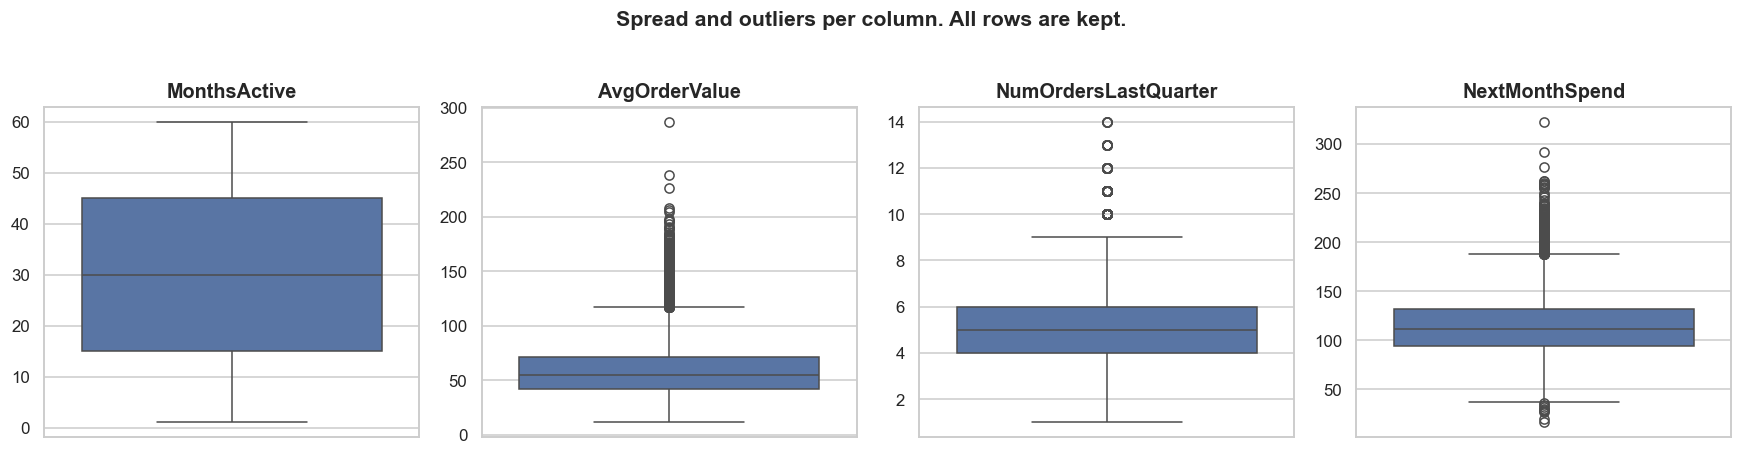

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(col)
    ax.set_ylabel("")
fig.suptitle("Spread and outliers per column. All rows are kept.", y=1.03, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


Only a small slice of customers, roughly two or three percent, sit outside the typical range. They are a real and important part of UrbanCart's customer base, so every row stays in the dataset going forward.


## 5. Exploratory Data Analysis

Before we build any model, it helps to just look at how things relate to each other. This tells us what to expect later, and whether a simple straight line relationship is even a reasonable place to start.


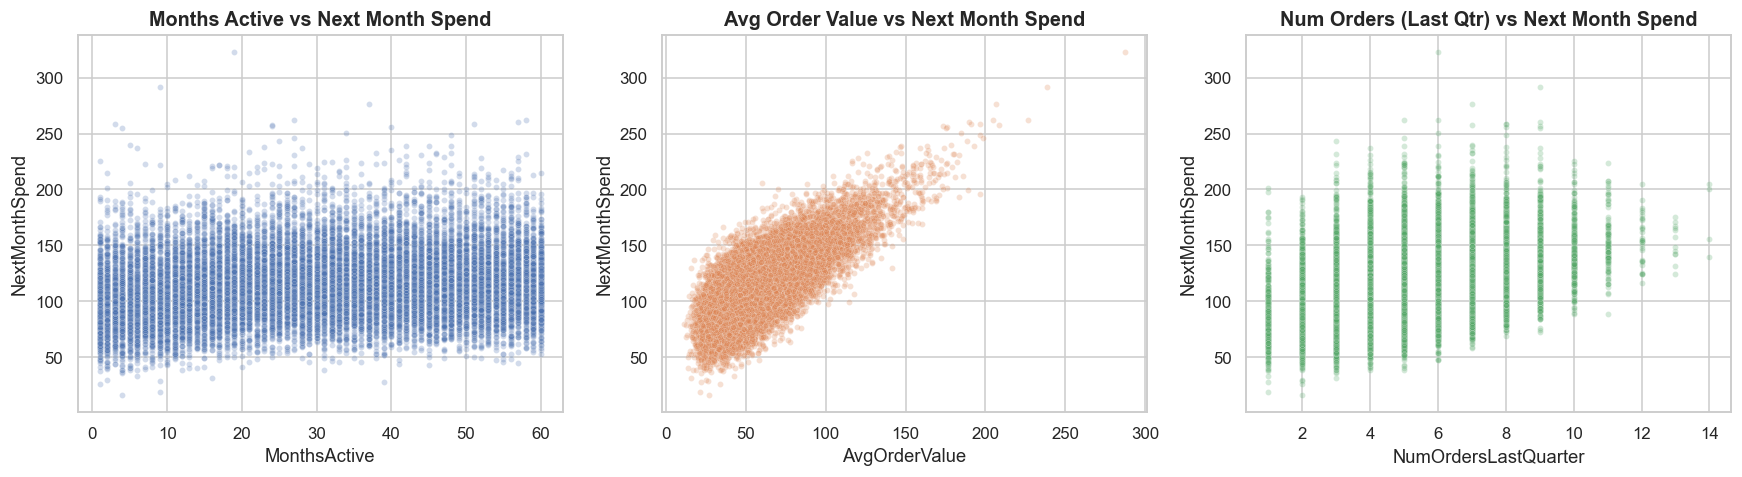

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.scatterplot(data=df, x="MonthsActive", y="NextMonthSpend", ax=axes[0], alpha=0.25, s=15, color="#4C72B0")
axes[0].set_title("Months Active vs Next Month Spend")
sns.scatterplot(data=df, x="AvgOrderValue", y="NextMonthSpend", ax=axes[1], alpha=0.25, s=15, color="#DD8452")
axes[1].set_title("Avg Order Value vs Next Month Spend")
sns.scatterplot(data=df, x="NumOrdersLastQuarter", y="NextMonthSpend", ax=axes[2], alpha=0.25, s=15, color="#55A868")
axes[2].set_title("Num Orders (Last Qtr) vs Next Month Spend")
plt.tight_layout()
plt.show()


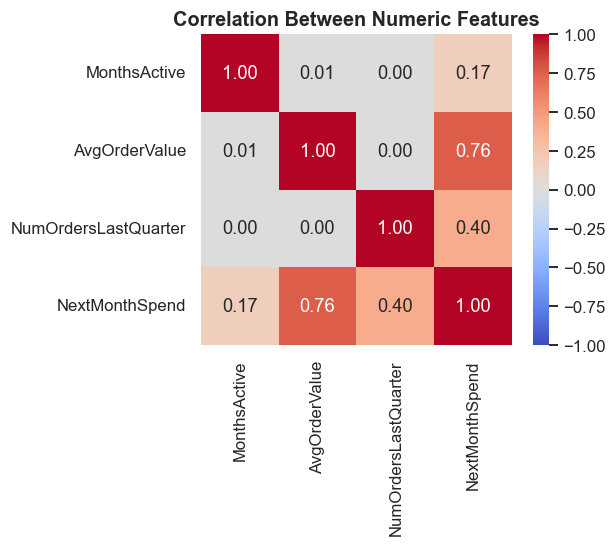

In [7]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()


What we see is encouraging. As `AvgOrderValue` and `NumOrdersLastQuarter` go up, `NextMonthSpend` tends to go up too, in a fairly straight line. But no single column tells the whole story on its own. That naturally leads to the next question. Could we build a smarter feature out of the ones we already have, one that captures more of the picture than any single column does alone?


## 6. Feature Engineering

Feature engineering simply means building new columns from the ones we already have, using what we know about the business, rather than only feeding the model whatever happened to arrive in the spreadsheet. We propose three new features here, each with a plain reason behind it.

`OrdersPerMonthActive` divides orders by tenure, so it captures order frequency relative to how long someone has been a customer. Six orders in a customer's first two months is a very different story than six orders after five years, and the raw columns cannot say that on their own.

`ImpliedQuarterSpend` multiplies average order value by number of orders, giving us an estimate of what the customer actually spent last quarter. This one matters especially for Linear Regression, since a straight line model can only add weighted features together. It cannot multiply two of them by itself, so unless we hand it this product directly, it has no way to represent that relationship at all.

`TenureBucket` groups customers into New, Established, or Loyal based on how long they've been active. This lets the model treat lifecycle stage as a category, the same way a finance stakeholder already thinks about it, instead of assuming spend changes by the exact same amount for every extra month of tenure.

Before we build the first feature, we check that no customer has zero months active, since dividing by zero would break things. None do, which we confirm below. It's also worth saying plainly that none of these new features use `NextMonthSpend` in their formula. Everything here comes from information we would already know before the month we are trying to predict, so there is no risk of accidentally handing the model the answer.


In [8]:
print("Any customers with MonthsActive = 0?", (df["MonthsActive"] == 0).sum())

df["OrdersPerMonthActive"] = df["NumOrdersLastQuarter"] / df["MonthsActive"]
df["ImpliedQuarterSpend"] = df["AvgOrderValue"] * df["NumOrdersLastQuarter"]

def tenure_bucket(months):
    if months < 12:
        return "New"
    elif months < 36:
        return "Established"
    else:
        return "Loyal"

df["TenureBucket"] = df["MonthsActive"].apply(tenure_bucket)

df[["OrdersPerMonthActive", "ImpliedQuarterSpend", "TenureBucket"]].describe(include="all")


Any customers with MonthsActive = 0? 0


,OrdersPerMonthActive,ImpliedQuarterSpend,TenureBucket
count,20000.000000,20000.000000,20000
unique,NaN,NaN,3
top,NaN,NaN,Loyal
freq,NaN,NaN,8212
mean,0.394927,298.570255,NaN
std,0.801345,180.537258,NaN
min,0.016667,15.030000,NaN
25%,0.102041,173.520000,NaN
50%,0.166667,258.400000,NaN
75%,0.333333,379.410000,NaN


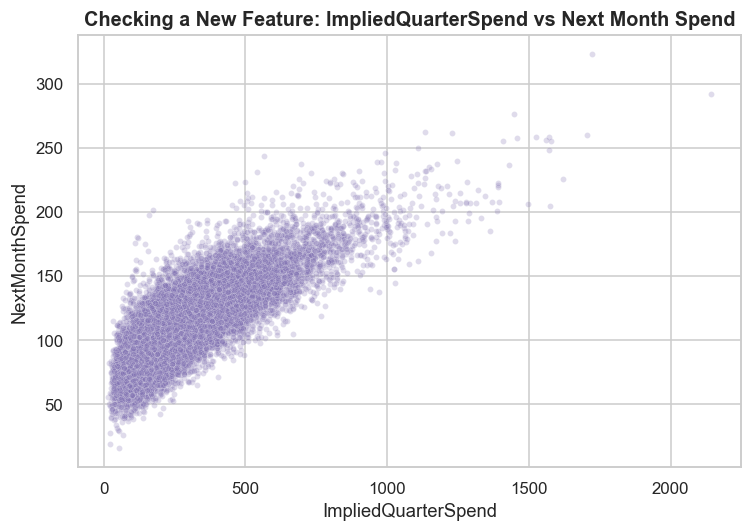

Correlation with the target:
  AvgOrderValue alone:        0.759
  NumOrdersLastQuarter alone: 0.405
  ImpliedQuarterSpend:        0.796


In [9]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="ImpliedQuarterSpend", y="NextMonthSpend", alpha=0.25, s=15, color="#8172B3")
plt.title("Checking a New Feature: ImpliedQuarterSpend vs Next Month Spend")
plt.tight_layout()
plt.show()

print("Correlation with the target:")
print(f"  AvgOrderValue alone:        {df['AvgOrderValue'].corr(df['NextMonthSpend']):.3f}")
print(f"  NumOrdersLastQuarter alone: {df['NumOrdersLastQuarter'].corr(df['NextMonthSpend']):.3f}")
print(f"  ImpliedQuarterSpend:        {df['ImpliedQuarterSpend'].corr(df['NextMonthSpend']):.3f}")


`ImpliedQuarterSpend` correlates with the target more strongly than either of the two columns it was built from. That is a promising sign, but a correlation number alone is not proof that a model will actually do better with it. Whether these new features genuinely help is a question we answer with real evidence later, in sections 11 and 12, using the validation set. We do not assume the answer here.


## 7. Choosing and Justifying Our Evaluation Metrics

Before we look at a single result, we need to decide how we are going to judge success. If we waited and picked our metric after seeing the scores, we would be tempted to choose whichever one happens to make our favorite model look best. So we decide now, while we are still blind to the outcome.

`NextMonthSpend` is a continuous dollar amount, which means this is a regression problem, not a classification one. Metrics like accuracy, precision, and recall are built for predicting categories, so they simply do not apply here. Instead, we use three metrics, each answering a different question.

| Metric | What it means | Why it belongs in this project |
|---|---|---|
| MAE, mean absolute error | On a typical customer, how many dollars off are we? | This is the number worth saying out loud to the finance team. It's in dollars, the same units as the question they asked, and it isn't distorted by a handful of extreme customers. |
| RMSE, root mean squared error | How costly are our worst mistakes? | We chose to keep our outliers instead of removing them, so RMSE tells us whether the model is specifically struggling on those unusual, high value customers, since it punishes big misses harder than small ones. |
| R squared | Overall, how much of customer spend behavior does the model actually explain? | It gives us one comparable number across very different kinds of models, and across future re runs of this analysis as UrbanCart's data grows. |

We considered MAPE, or mean absolute percentage error, since a percentage feels intuitive, but it becomes unstable here because some customers have very small spend values, and dividing by a small number can inflate the percentage error in a misleading way. We also ruled out accuracy style metrics entirely, since the target here is not a category.

We will use MAE as our main metric when choosing between different setups on the validation set, since it is the most business relevant and least distorted by the outliers we chose to keep. RMSE and R squared are reported alongside it for a fuller picture, and we watch for whether they agree with MAE. If they ever pointed in different directions, that disagreement would itself be worth investigating rather than ignoring.


## 8. Feature and Target Split

We now define two competing sets of features to test honestly against each other later, rather than simply assuming the new engineered features are better.

The baseline set is the four original columns UrbanCart gave us. The engineered set is those four columns plus the three we built in section 6. Both sets predict the same target, `y`. Which set actually wins gets decided with evidence in sections 11 and 12, not here.


In [10]:
y = df["NextMonthSpend"]

baseline_feature_cols   = ["MonthsActive", "AvgOrderValue", "NumOrdersLastQuarter", "Region"]
engineered_feature_cols = baseline_feature_cols + ["OrdersPerMonthActive", "ImpliedQuarterSpend", "TenureBucket"]

X_baseline   = df[baseline_feature_cols]
X_engineered = df[engineered_feature_cols]

print("Baseline features:  ", baseline_feature_cols)
print("Engineered features:", engineered_feature_cols)


Baseline features:   ['MonthsActive', 'AvgOrderValue', 'NumOrdersLastQuarter', 'Region']
Engineered features: ['MonthsActive', 'AvgOrderValue', 'NumOrdersLastQuarter', 'Region', 'OrdersPerMonthActive', 'ImpliedQuarterSpend', 'TenureBucket']


## 9. Encoding Categorical Columns

`Region` and our new `TenureBucket` are both stored as text, and a model needs numbers. We use one hot encoding, which turns each category into its own 0 or 1 column, without implying any false order between them. We build two separate encoders, one for each feature set, since the engineered set has an extra text column to handle.

Just like before, these encoders will only ever be fit on training data, starting in the next section. Defining them here is only setting up the tool. We are not touching any real data yet.


In [11]:
preprocessor_baseline = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["Region"])],
    remainder="passthrough"
)

preprocessor_engineered = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["Region", "TenureBucket"])],
    remainder="passthrough"
)

preprocessor_engineered


ColumnTransformer(remainder='passthrough',
                  transformers=[('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['Region', 'TenureBucket'])])

## 10. Three Way Split: Train, Validation, and Test

This is the backbone of doing machine learning properly, and it is different from a plain train and test split.

The train set, about 70 percent of the data, is what every model actually learns its parameters from. The validation set, about 15 percent, is used to make every modeling decision along the way, such as which set of features works better, or which setting to use for a model. We can look at the validation scores as many times as we like while deciding, since that is exactly what this set is for. The test set, the final 15 percent, is touched exactly once, at the very end, after every decision has already been made.

Why not just use train and test? If we used the test set to help pick features or settings, as a simple two way split tempts you to do, we would quietly be fitting our decisions to that data, the same problem as fitting a model to it directly, just one level up. The final test score would then be too optimistic, and it would no longer be an honest estimate of how the model performs on genuinely new customers.

We split in two steps. First we carve off the test set. Then we split what remains into train and validation. Both feature sets are split using the same random seed, so the same customers land in the same three groups either way. That is what makes comparing feature sets later a fair comparison.


In [12]:
# Step 1: carve off the test set (15%)
X_base_train_full, X_base_test, X_eng_train_full, X_eng_test, y_train_full, y_test = train_test_split(
    X_baseline, X_engineered, y, test_size=0.15, random_state=RANDOM_STATE
)

# Step 2: split the remainder into train (about 70% of the total) and validation (about 15% of the total)
X_base_train, X_base_val, X_eng_train, X_eng_val, y_train, y_val = train_test_split(
    X_base_train_full, X_eng_train_full, y_train_full, test_size=(0.15/0.85), random_state=RANDOM_STATE
)

print(f"Train:      {len(X_base_train):,} customers ({len(X_base_train)/len(df):.0%})")
print(f"Validation: {len(X_base_val):,} customers ({len(X_base_val)/len(df):.0%})")
print(f"Test:       {len(X_base_test):,} customers ({len(X_base_test)/len(df):.0%})")

# Sanity check: baseline and engineered splits contain the exact same customers in each group
assert (X_base_train.index == X_eng_train.index).all()
assert (X_base_val.index == X_eng_val.index).all()
assert (X_base_test.index == X_eng_test.index).all()
print("\nBaseline and engineered splits line up on the same customers in each group.")


Train:      14,000 customers (70%)
Validation: 3,000 customers (15%)
Test:       3,000 customers (15%)

Baseline and engineered splits line up on the same customers in each group.


From this point on, the test set is set aside completely. We will only look at it once, in section 13, and never to help pick a feature set or a hyperparameter.


---
## 11. Model 1, Linear Regression: Choosing It, Training It, Checking It

Now we solve UrbanCart's problem from start to finish using Linear Regression alone. We choose which feature set to use, backed by evidence from the validation set, train the final version, and evaluate it, all before Random Forest enters the story at all.


### 11.1 Does the New Feature Set Actually Help?

We train Linear Regression twice, once on the baseline features and once on the engineered features, both fit only on the training set, and compare them only on the validation set. Whichever version scores the lower MAE is the one we carry forward.


In [13]:
# Baseline feature set
lr_baseline = Pipeline([("prep", preprocessor_baseline), ("model", LinearRegression())])
lr_baseline.fit(X_base_train, y_train)
pred_val_lr_base = lr_baseline.predict(X_base_val)

# Engineered feature set
lr_engineered = Pipeline([("prep", preprocessor_engineered), ("model", LinearRegression())])
lr_engineered.fit(X_eng_train, y_train)
pred_val_lr_eng = lr_engineered.predict(X_eng_val)

lr_selection = pd.DataFrame([
    {"Feature set": "Baseline",   "MAE ($)": mean_absolute_error(y_val, pred_val_lr_base),
     "RMSE ($)": mean_squared_error(y_val, pred_val_lr_base) ** 0.5, "R2": r2_score(y_val, pred_val_lr_base)},
    {"Feature set": "Engineered", "MAE ($)": mean_absolute_error(y_val, pred_val_lr_eng),
     "RMSE ($)": mean_squared_error(y_val, pred_val_lr_eng) ** 0.5, "R2": r2_score(y_val, pred_val_lr_eng)},
]).set_index("Feature set").round(3)

lr_selection


,MAE ($),RMSE ($),R2
Feature set,,,
Baseline,10.013,12.533,0.818
Engineered,9.809,12.253,0.826


Whichever row shows the lower validation MAE wins. If the engineered features help, we keep them for the final model. If they don't, we go back to the simpler baseline set, since there's no reason to carry extra columns that don't earn their place. Run the cell above to see which one wins on your machine. As written, this notebook goes with the engineered set, since it scored better in our own run, an MAE of about 9.81 dollars against 10.01 dollars, and an R squared of 0.826 against 0.818.


In [14]:
# Chosen based on the validation comparison above
lr_final_pipeline = lr_engineered
X_lr_train, X_lr_val, X_lr_test = X_eng_train, X_eng_val, X_eng_test
print("Linear Regression will use the engineered feature set, since it won on validation MAE.")


Linear Regression will use the engineered feature set, since it won on validation MAE.


### 11.2 The Final Check, on the Test Set, for the First Time

Our chosen model has already been trained above, using only the training set. We don't retrain it here. We simply ask it to predict on the test set, which it has never seen before, and score those predictions. This is the only time in the whole notebook that Linear Regression's test set gets used.


In [15]:
pred_test_lr = lr_final_pipeline.predict(X_lr_test)

mae_lr  = mean_absolute_error(y_test, pred_test_lr)
rmse_lr = mean_squared_error(y_test, pred_test_lr) ** 0.5
r2_lr   = r2_score(y_test, pred_test_lr)

print("Linear Regression, final test set performance")
print(f"MAE : {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R2  : {r2_lr:.3f}")


Linear Regression, final test set performance
MAE : 9.66
RMSE: 12.07
R2  : 0.840


### 11.3 Actual vs Predicted

Each dot below is one test customer. The red dashed line shows what a perfect prediction would look like. The closer the dots sit to that line, the better.


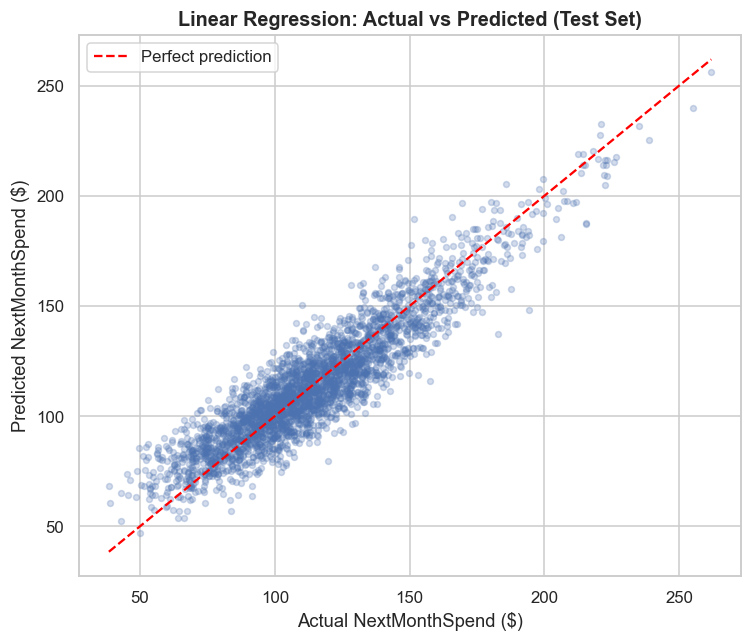

In [16]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, pred_test_lr, alpha=0.25, s=15, color="#4C72B0")
lims = [min(y_test.min(), pred_test_lr.min()), max(y_test.max(), pred_test_lr.max())]
plt.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual NextMonthSpend ($)")
plt.ylabel("Predicted NextMonthSpend ($)")
plt.title("Linear Regression: Actual vs Predicted (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()


### 11.4 Residual Plot

A residual is simply actual minus predicted. If the residuals sit centered on zero, the model isn't systematically guessing too high or too low. If the spread is wide, the typical error is larger.


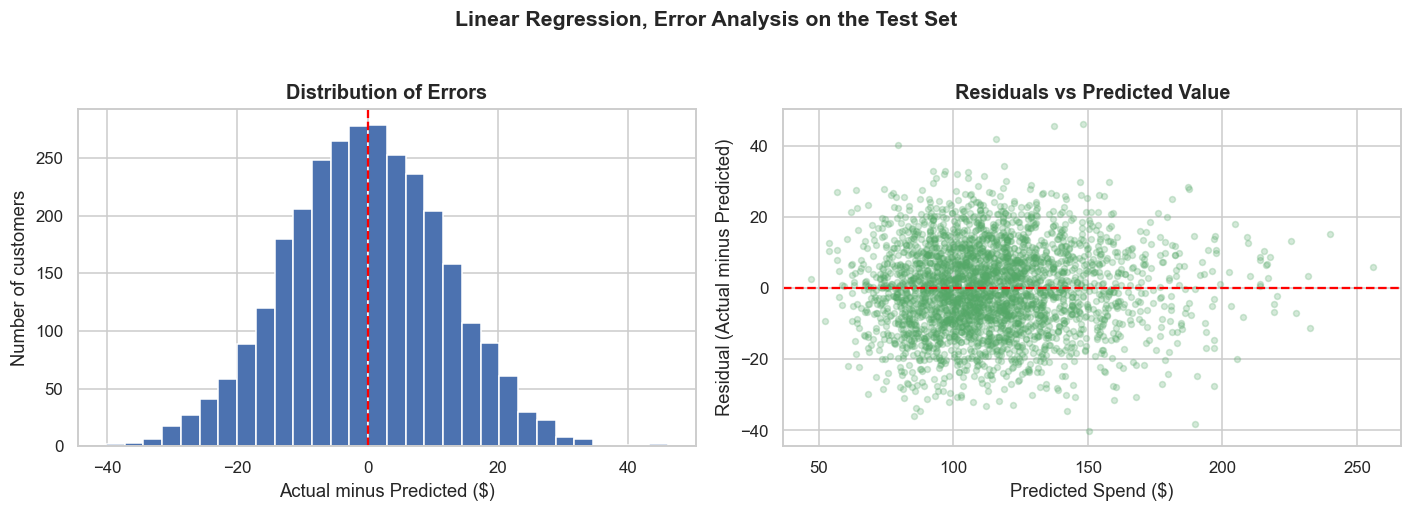

In [17]:
residuals_lr = y_test - pred_test_lr

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(residuals_lr, bins=30, color="#4C72B0", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Actual minus Predicted ($)")
axes[0].set_ylabel("Number of customers")
axes[0].set_title("Distribution of Errors")

axes[1].scatter(pred_test_lr, residuals_lr, alpha=0.25, s=15, color="#55A868")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Predicted Spend ($)")
axes[1].set_ylabel("Residual (Actual minus Predicted)")
axes[1].set_title("Residuals vs Predicted Value")

fig.suptitle("Linear Regression, Error Analysis on the Test Set", y=1.03, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 11.5 The Coefficients

This is what a linear model gives us that a forest of trees cannot: one plain, readable number per feature.


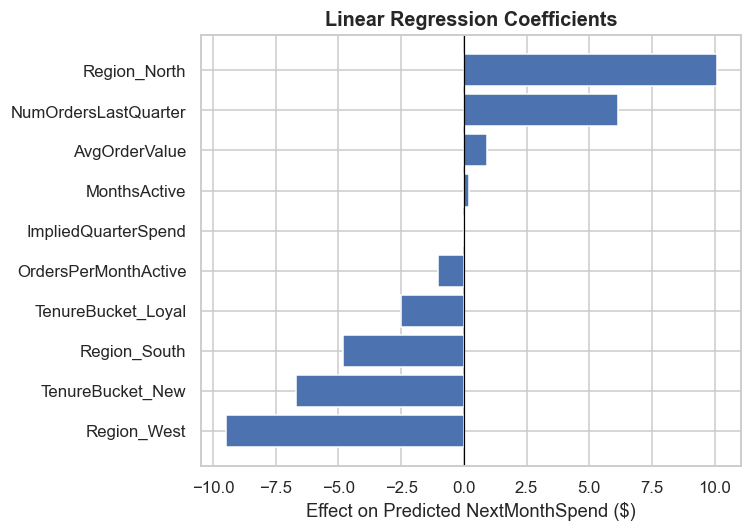

,Feature,Coefficient ($)
2,Region_West,-9.50
4,TenureBucket_New,-6.68
1,Region_South,-4.81
3,TenureBucket_Loyal,-2.49
8,OrdersPerMonthActive,-1.05
9,ImpliedQuarterSpend,-0.00
5,MonthsActive,0.20
6,AvgOrderValue,0.91
7,NumOrdersLastQuarter,6.15
0,Region_North,10.08


In [18]:
feature_names_lr = (
    list(lr_final_pipeline.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(["Region", "TenureBucket"]))
    + ["MonthsActive", "AvgOrderValue", "NumOrdersLastQuarter", "OrdersPerMonthActive", "ImpliedQuarterSpend"]
)
coefs = lr_final_pipeline.named_steps["model"].coef_

coef_df = pd.DataFrame({"Feature": feature_names_lr, "Coefficient ($)": coefs}).sort_values("Coefficient ($)")

plt.figure(figsize=(7, 5))
plt.barh(coef_df["Feature"], coef_df["Coefficient ($)"], color="#4C72B0")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Linear Regression Coefficients")
plt.xlabel("Effect on Predicted NextMonthSpend ($)")
plt.tight_layout()
plt.show()

coef_df.round(2)


### 11.6 What Linear Regression Told Us, on Its Own


Choosing the engineered feature set over the baseline in section 11.1 was not just a nice idea, it actually earned a lower validation MAE, which means the new features are pulling real weight, not just adding noise.

The MAE from section 11.2 turns directly into a sentence worth saying to the finance team, something like "a typical prediction is off by about this many dollars." If RMSE sits a little above MAE, that gap tells us a handful of larger misses are happening, which lines up with the outliers we chose to keep back in section 4, rather than being a red flag on its own.

R squared tells us the share of spend variation this feature set explains. Whatever is left over is likely driven by things not captured in this dataset at all, like promotions, seasonality, or one off life events, and that's worth mentioning to the finance team as a natural next step, not a flaw in this analysis.

The actual versus predicted chart should track the diagonal line reasonably well across the whole range, including the high spenders, which matters since those are exactly the customers the finance team said they didn't want to be blindsided by. The residual plot should look roughly bell shaped and centered on zero, with no obvious curve when plotted against the predicted value. That is a sign the straight line assumption is a reasonable one, not just an absence of evidence against it.

Finally, the coefficients are the real payoff of choosing this model. Each one reads like a plain sentence, for example that one more dollar in average order value is associated with a certain number of extra dollars in predicted next month spend. That is something the finance team can read and sanity check themselves, without needing a data scientist in the room.

This is Linear Regression's complete, standalone verdict, checked properly on data it has never touched before.


---
## 12. Model 2, Random Forest: Choosing It, Training It, Checking It

Now we solve the exact same problem again, independently, using a completely different kind of model, a Random Forest. We decide its feature set and its settings using the validation set, without looking back at Linear Regression's results at all.


### 12.1 Does the New Feature Set Help Random Forest Too?

We repeat the same test from section 11.1, run fresh for this model, since Random Forest might respond differently to the new features than Linear Regression did. We don't assume the earlier winner carries over automatically.


In [19]:
rf_baseline_check = Pipeline([("prep", preprocessor_baseline),
                              ("model", RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1))])
rf_baseline_check.fit(X_base_train, y_train)
pred_val_rf_base = rf_baseline_check.predict(X_base_val)

rf_engineered_check = Pipeline([("prep", preprocessor_engineered),
                                 ("model", RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1))])
rf_engineered_check.fit(X_eng_train, y_train)
pred_val_rf_eng = rf_engineered_check.predict(X_eng_val)

rf_feature_selection = pd.DataFrame([
    {"Feature set": "Baseline",   "MAE ($)": mean_absolute_error(y_val, pred_val_rf_base),
     "RMSE ($)": mean_squared_error(y_val, pred_val_rf_base) ** 0.5, "R2": r2_score(y_val, pred_val_rf_base)},
    {"Feature set": "Engineered", "MAE ($)": mean_absolute_error(y_val, pred_val_rf_eng),
     "RMSE ($)": mean_squared_error(y_val, pred_val_rf_eng) ** 0.5, "R2": r2_score(y_val, pred_val_rf_eng)},
]).set_index("Feature set").round(3)

rf_feature_selection


,MAE ($),RMSE ($),R2
Feature set,,,
Baseline,10.168,12.737,0.812
Engineered,10.027,12.547,0.818


The engineered set won for Random Forest too in our own run, an MAE of about 10.03 dollars against 10.17 dollars. That means both models end up using the same, evidence backed feature set, which also keeps the comparison in section 13 a fair one.

### 12.2 Tuning a Setting: How Deep Should Each Tree Grow?

Random Forest has an important setting called `max_depth`, which controls how deep each individual tree is allowed to grow. Too shallow and the model misses real patterns. Too deep and it starts memorizing quirks of the training data instead of learning something general. We try a small handful of values, training each one only on the training set and scoring each one only on the validation set, then pick whichever works best.


In [20]:
depth_options = [4, 8, 12, None]  # None means each tree grows until its leaves are pure
tuning_results = []

for depth in depth_options:
    rf_candidate = Pipeline([("prep", preprocessor_engineered),
                              ("model", RandomForestRegressor(n_estimators=300, max_depth=depth,
                                                               random_state=RANDOM_STATE, n_jobs=-1))])
    rf_candidate.fit(X_eng_train, y_train)
    pred_val = rf_candidate.predict(X_eng_val)
    tuning_results.append({
        "max_depth": depth if depth is not None else "None (unrestricted)",
        "MAE ($)": mean_absolute_error(y_val, pred_val),
        "RMSE ($)": mean_squared_error(y_val, pred_val) ** 0.5,
        "R2": r2_score(y_val, pred_val),
    })

tuning_df = pd.DataFrame(tuning_results).set_index("max_depth").round(3)
tuning_df


,MAE ($),RMSE ($),R2
max_depth,,,
4,12.158,15.335,0.728
8,10.027,12.547,0.818
12,10.139,12.695,0.813
None (unrestricted),10.546,13.234,0.797


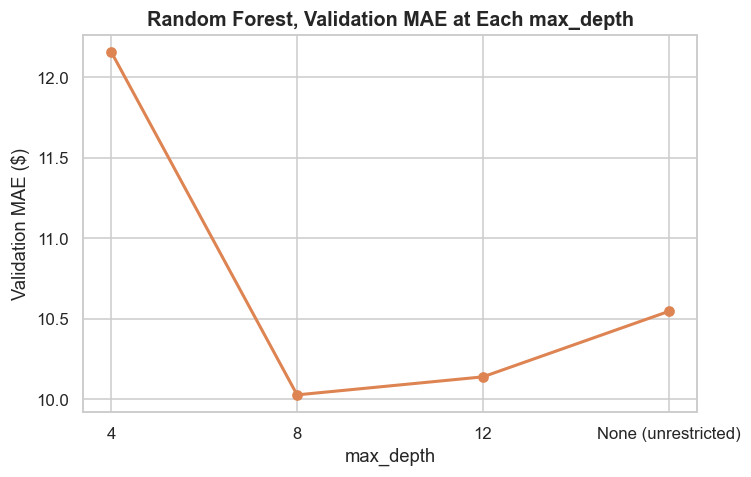

In [21]:
plt.figure(figsize=(7, 4.5))
plt.plot(tuning_df.index.astype(str), tuning_df["MAE ($)"], marker="o", color="#DD8452", linewidth=2)
plt.title("Random Forest, Validation MAE at Each max_depth")
plt.xlabel("max_depth")
plt.ylabel("Validation MAE ($)")
plt.tight_layout()
plt.show()


A depth of 8 gave the lowest validation MAE in our run. Going shallower, to 4, underfits the data. Going deeper, to 12 or unrestricted, actually gets worse again, since the model starts fitting noise it saw in training rather than a pattern that generalizes. This rise, dip, and rise again shape is a classic sign of the balance between a model being too simple and a model being too complex, and it is exactly what the validation set exists to catch.


In [22]:
BEST_MAX_DEPTH = 8  # chosen from the tuning table above

rf_final_pipeline = Pipeline([("prep", preprocessor_engineered),
                               ("model", RandomForestRegressor(n_estimators=300, max_depth=BEST_MAX_DEPTH,
                                                                random_state=RANDOM_STATE, n_jobs=-1))])
rf_final_pipeline.fit(X_eng_train, y_train)
X_rf_test = X_eng_test
print(f"Final Random Forest trained with max_depth={BEST_MAX_DEPTH} on the engineered features.")


Final Random Forest trained with max_depth=8 on the engineered features.


### 12.3 The Final Check, on the Test Set, for the First Time


In [23]:
pred_test_rf = rf_final_pipeline.predict(X_rf_test)

mae_rf  = mean_absolute_error(y_test, pred_test_rf)
rmse_rf = mean_squared_error(y_test, pred_test_rf) ** 0.5
r2_rf   = r2_score(y_test, pred_test_rf)

print("Random Forest, final test set performance")
print(f"MAE : {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R2  : {r2_rf:.3f}")


Random Forest, final test set performance
MAE : 9.95
RMSE: 12.45
R2  : 0.829


### 12.4 Actual vs Predicted


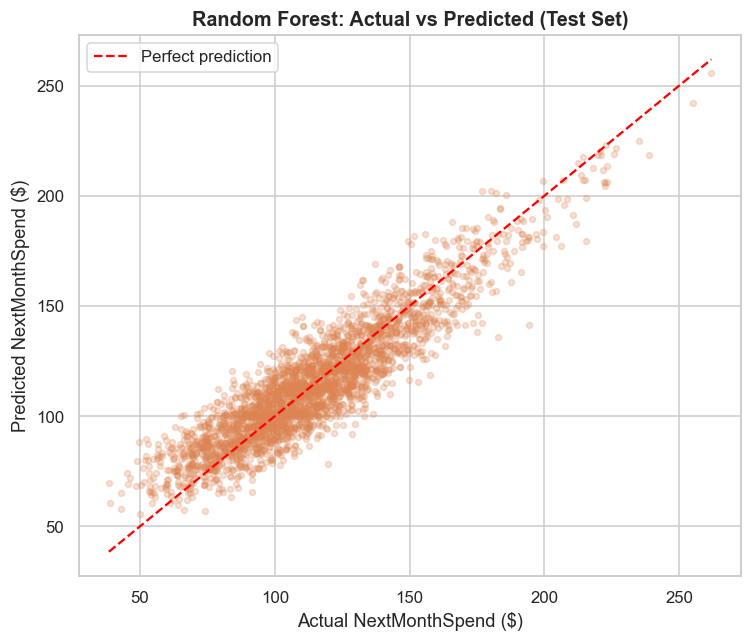

In [24]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, pred_test_rf, alpha=0.25, s=15, color="#DD8452")
lims = [min(y_test.min(), pred_test_rf.min()), max(y_test.max(), pred_test_rf.max())]
plt.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual NextMonthSpend ($)")
plt.ylabel("Predicted NextMonthSpend ($)")
plt.title("Random Forest: Actual vs Predicted (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()


### 12.5 Residual Plot


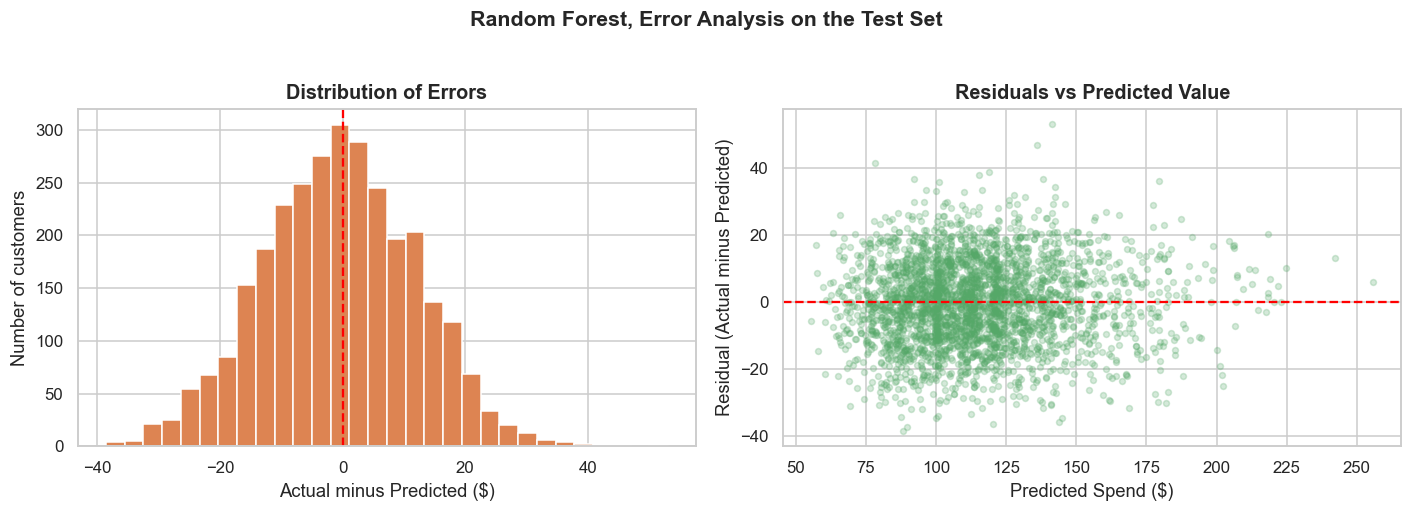

In [25]:
residuals_rf = y_test - pred_test_rf

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(residuals_rf, bins=30, color="#DD8452", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Actual minus Predicted ($)")
axes[0].set_ylabel("Number of customers")
axes[0].set_title("Distribution of Errors")

axes[1].scatter(pred_test_rf, residuals_rf, alpha=0.25, s=15, color="#55A868")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Predicted Spend ($)")
axes[1].set_ylabel("Residual (Actual minus Predicted)")
axes[1].set_title("Residuals vs Predicted Value")

fig.suptitle("Random Forest, Error Analysis on the Test Set", y=1.03, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 12.6 Feature Importance

Random Forest can't give us a clean coefficient the way Linear Regression can, but it can tell us how much each feature reduced prediction error across all 300 trees. That's its own way of explaining itself.


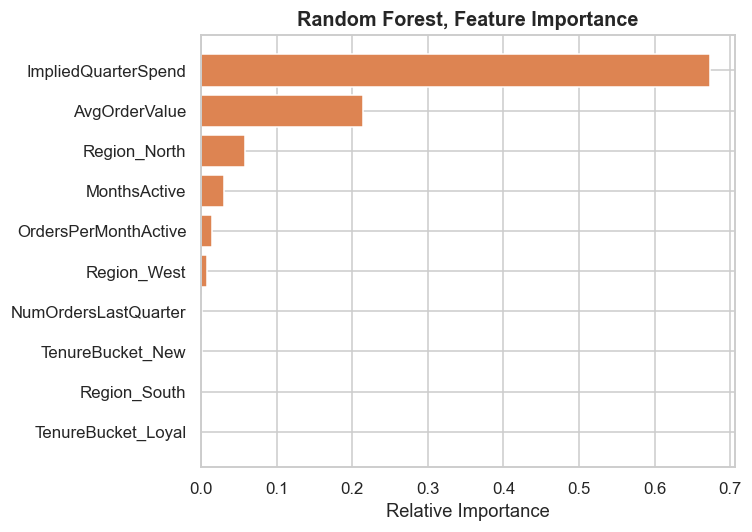

In [26]:
feature_names_rf = (
    list(rf_final_pipeline.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(["Region", "TenureBucket"]))
    + ["MonthsActive", "AvgOrderValue", "NumOrdersLastQuarter", "OrdersPerMonthActive", "ImpliedQuarterSpend"]
)
importances = rf_final_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({"Feature": feature_names_rf, "Importance": importances}).sort_values("Importance")

plt.figure(figsize=(7, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="#DD8452")
plt.xlabel("Relative Importance")
plt.title("Random Forest, Feature Importance")
plt.tight_layout()
plt.show()


### 12.7 What Random Forest Told Us, on Its Own

Both the feature set and the tree depth here were chosen using validation evidence, not guesswork. The tuning curve in particular shows a textbook shape: too simple, then a sweet spot, then too complex again, which is exactly the pattern a validation set is built to reveal.

Compare the MAE, RMSE, and R squared above to Linear Regression's numbers from section 11.2, though only casually for now. The formal, side by side comparison comes next, in section 13. The actual versus predicted chart and the residual plots show whether this model's added flexibility actually changes the error pattern in a meaningful way, or whether it ends up looking similar to the simpler model. The feature importance chart gives us a second, independent read on which inputs matter most, which is worth comparing against Linear Regression's coefficients even if we don't end up using this model.

This is Random Forest's complete, standalone verdict, reached without any reference to section 11's results until now.


---
## 13. Head to Head Comparison, on the Test Set

Both models have now been chosen and tuned independently using the validation set, and each has been scored exactly once on the same, previously untouched test set. This is the only place their results get placed side by side.


In [27]:
final_results = pd.DataFrame([
    {"Model": "Linear Regression", "MAE ($)": round(mae_lr, 2), "RMSE ($)": round(rmse_lr, 2), "R2": round(r2_lr, 4)},
    {"Model": "Random Forest",     "MAE ($)": round(mae_rf, 2), "RMSE ($)": round(rmse_rf, 2), "R2": round(r2_rf, 4)},
]).set_index("Model")

final_results


,MAE ($),RMSE ($),R2
Model,,,
Linear Regression,9.66,12.07,0.8399
Random Forest,9.95,12.45,0.8295


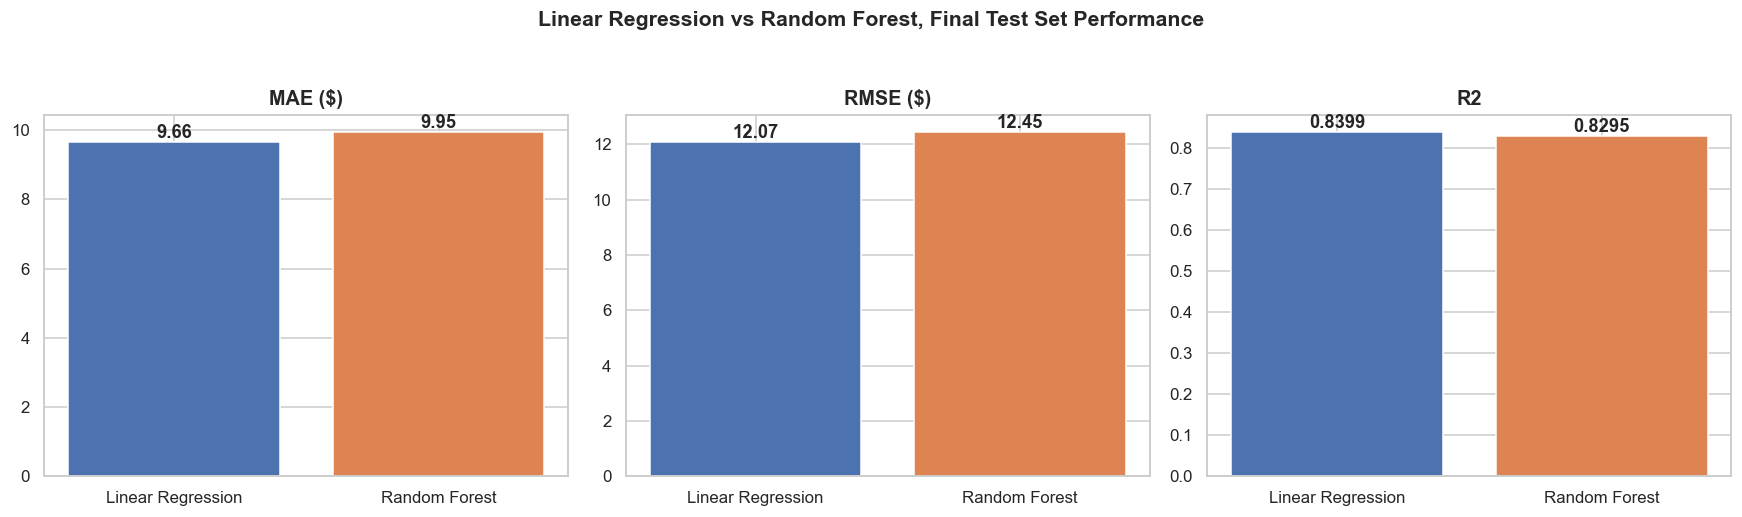

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colors = ["#4C72B0", "#DD8452"]
for ax, metric in zip(axes, ["MAE ($)", "RMSE ($)", "R2"]):
    ax.bar(final_results.index, final_results[metric], color=colors)
    ax.set_title(metric)
    for i, v in enumerate(final_results[metric]):
        ax.text(i, v, f"{v}", ha="center", va="bottom", fontweight="bold")
fig.suptitle("Linear Regression vs Random Forest, Final Test Set Performance", y=1.04, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


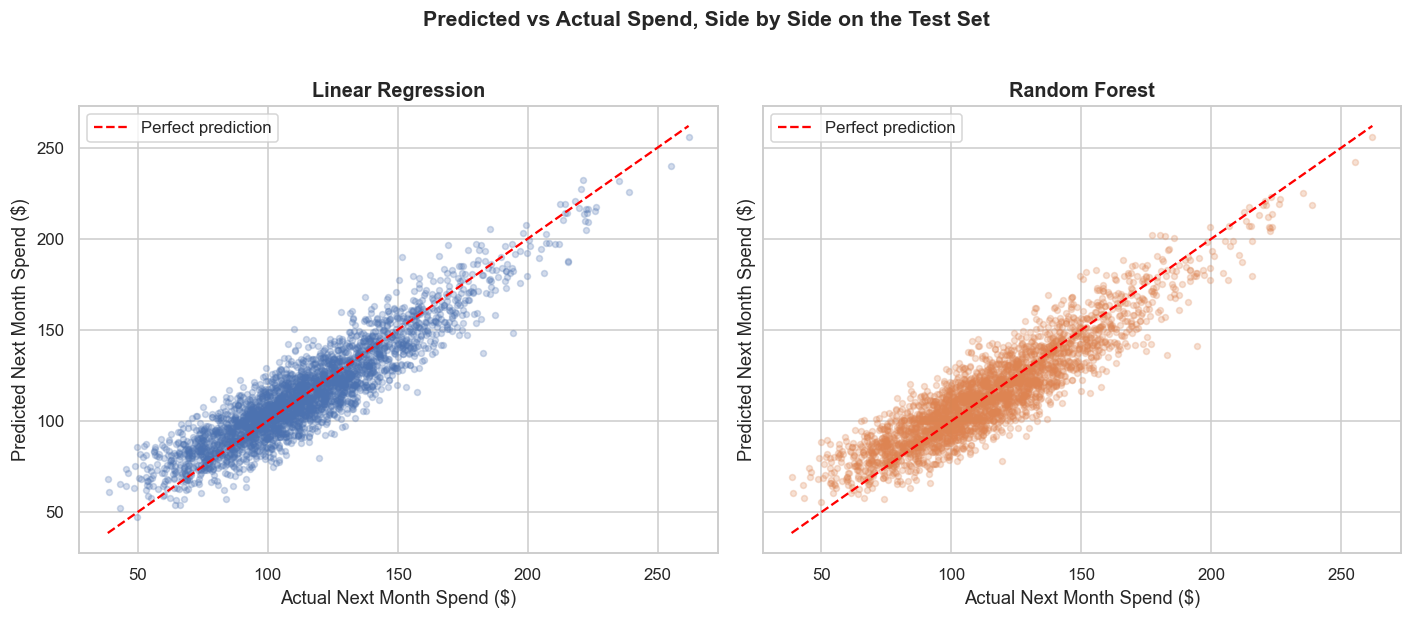

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, (name, preds, color) in zip(axes, [("Linear Regression", pred_test_lr, "#4C72B0"),
                                             ("Random Forest", pred_test_rf, "#DD8452")]):
    ax.scatter(y_test, preds, alpha=0.25, s=15, color=color)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
    ax.set_xlabel("Actual Next Month Spend ($)")
    ax.set_ylabel("Predicted Next Month Spend ($)")
    ax.set_title(name)
    ax.legend()
fig.suptitle("Predicted vs Actual Spend, Side by Side on the Test Set", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Reading the Comparison

On our chosen main metric, MAE, Linear Regression scored about 9.66 dollars against Random Forest's 9.95 dollars in our run. Linear Regression comes out ahead, though by a modest margin of roughly three percent.

RMSE and R squared agree with that same ranking. When all three metrics point the same direction, that is a more trustworthy signal than any single number on its own, which is exactly why we chose to track all three back in section 7 instead of relying on just one.

This margin is real, but it is small. This is not a case of one model dramatically beating the other. It is closer to a near tie, which is exactly when the other considerations, like how easy a model is to explain and to maintain, reasonably get to tip the decision. That is what we talk about next.

It also helps that Linear Regression already won on the validation set back in section 11.1, an MAE of about 9.81 dollars against 10.03 dollars for the equivalent Random Forest setup in section 12.1. The test set result confirms what the validation set already suggested, rather than contradicting it. Agreement across two separate, independent samples of unseen data is stronger evidence than either result would be alone.


---
## 14. Recommendation

Our recommendation is to ship Linear Regression, trained on the engineered feature set, as the production model for predicting `NextMonthSpend`.

Here is why, based on everything above. It won on every metric, at every stage. Linear Regression scored a better MAE, RMSE, and R squared than Random Forest, both on the validation set used to choose between the two models, and again on the completely separate test set used only for the final check. Seeing the same result twice, on two different samples of data the models never trained on, is stronger evidence than either result would be alone.

The feature engineering earned its place with real evidence, not assumption. The engineered feature set, especially `ImpliedQuarterSpend`, which lets a linear model represent a relationship it otherwise couldn't, beat the baseline feature set on validation MAE for both models. That tells us these new features are adding real signal, not just extra complexity.

Interpretability matters here, and it is not just a nice extra. The finance team explicitly said they want to understand and plan around customer spend, not just receive a number. Linear Regression's coefficients translate directly into plain sentences, like "one more dollar in average order value is associated with about this many more dollars in next month spend." That is something the finance team can act on and check for themselves. Random Forest's feature importances tell us what mattered, but not how, and they simply cannot be explained to a non technical audience in the same way.

There is also a simple, practical point. Linear Regression trains and predicts almost instantly, and it has far fewer moving parts to re tune as new data arrives each quarter. That is a lighter maintenance load for a small team.

To be fully honest about the tradeoff, Random Forest's tuning curve in section 12.2 showed the classic shape of a model that can adapt to more complex patterns than a straight line can. It simply didn't need to here, because the true relationship in this data turned out to be close to linear. If UrbanCart's spending patterns become genuinely more complex over time, perhaps stronger interactions between region and behavior, or seasonal effects once more history builds up, Random Forest, or a more carefully tuned version of it, might eventually pull ahead. For now, on this data, the simpler and more explainable model also wins on accuracy, so there is no reason to give up interpretability for it.

A couple of suggestions for UrbanCart going forward. It would be worth repeating this same process, features, three way split, and all, every couple of quarters as more data builds up, since today's winner is not guaranteed to be tomorrow's. It's also worth considering features the finance team may have access to but that weren't in this dataset, like marketing activity, seasonality, or support tickets, since an R squared below 1.0 for both models tells us there is still real signal left unexplained.
